# Generate GIF for vertical profiles

In [3]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import time
import cartopy.crs as ccrs
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [5]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:38975")
client

<Client: 'tcp://127.0.0.1:38975' processes=8 threads=32, memory=123.95 GiB>

In [6]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [7]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [8]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [9]:
# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

# open THETA zarr store - [degC]
theta_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options).THETA

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

# open density zarr store - [kg m-3]
rho_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/RHOAnoma_AVG_DAILY.ZARR/', s3_options).RHOAnoma + 1027.5

In [10]:
# carve out beaufort region
salt_beaufort = salt_da.isel(i=slice(450,750),j=slice(110,390))
theta_beaufort = theta_da.isel(i=slice(450,750),j=slice(110,390))
ice_beaufort = ice_da.isel(i=slice(450,750),j=slice(110,390))
rho_beaufort = rho_da.isel(i=slice(450,750),j=slice(110,390))

grid_beaufort = HH_grid.isel(i=slice(450,750),j=slice(110,390),k=slice(0,26)) # upper 150 m

HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)
HH_land_beaufort = HH_grid_land.isel(i=slice(450,750),j=slice(110,390))

In [11]:
temp_da = theta_beaufort.isel(k=slice(0,26)) # upper 150 m
salt_da = salt_beaufort.isel(k=slice(0,26)) 
rho_da = rho_beaufort.isel(k=slice(0,26)) 

In [12]:
def calculate_cp_from_profile(salinity, temperature, depth, lon=-137, lat=70):
    """
    Calculate specific heat capacity (cp) of seawater from depth, temperature, and salinity.
    
    Parameters:
    - salinity (array): salinity (PSU)
    - temperature (array): temperature (°C)
    - depth (array): depth values (m, negative downward)
    - lon (float): longitude for SA calculation
    - lat (float): latitude for pressure calculation
    
    Args:
    - cp (array): Specific heat capacity (J/kg/deg K) for each depth level
    """
    # Convert depth (m) to pressure (dbar)
    pressure = gsw.p_from_z(depth, lat)  # Negative depth because z is negative downward
    
    # Convert Practical Salinity (SP) to Absolute Salinity (SA)
    SA = gsw.SA_from_SP(salinity, pressure, lon, lat)
    
    # Compute specific heat capacity (cp) in J/(kg K)
    cp = gsw.cp_t_exact(SA, temperature, pressure)
    
    return cp

In [13]:
def calculate_mld(sigma0_array, density_threshold=0.03):
    """
    Calculate the Mixed Layer Depth (MLD) from a 4D potential density dataset (time, i, j, k),
    defined as the first depth where density exceeds surface density + threshold.

    If the profile contains no values exceeding the threshold but still has valid data,
    the MLD is defined as the bottommost valid depth in the profile.

    Handles land-masked grid cells (all-NaN profiles) by returning NaN.
    Compatible with Dask via rechunking along the vertical dimension (k).

    Args:
        sigma0_array (xr.DataArray): Potential density with dims (time, i, j, k) and vertical coord 'Z'.
        density_threshold (float): Threshold above surface density to define MLD (default 0.03 kg/m³).

    Returns:
        mld (xr.DataArray): MLD (depth) with dims (time, i, j).
        mld_k_index (xr.DataArray): Index along 'k' where threshold is first exceeded or last valid depth.
    """

    # Surface density at k=0
    rho_surface = sigma0_array.isel(k=0)

    # Density threshold
    threshold = rho_surface + density_threshold

    # Depth coordinate along 'k'
    depth_coord = sigma0_array['Z']

    # Ensure vertical dim is in a single chunk for Dask
    sigma0_array = sigma0_array.chunk(dict(k=-1))

    # Helper function to return both depth and index
    def first_exceeding_level_and_index(profile, depth, threshold_val):
        if np.all(np.isnan(profile)):
            return np.nan, np.nan
        for k in range(profile.shape[0]):
            if profile[k] > threshold_val and not np.isnan(profile[k]):
                return depth[k], k
        # If no threshold exceeded, return the deepest valid depth
        # Loop backwards over the vertical profile, from the bottom to the top.
        for k in range(profile.shape[0] - 1, -1, -1):
            if not np.isnan(profile[k]):
                return depth[k], k
        return np.nan, np.nan  # fallback; should not be hit

    # Apply with vectorization and dask support
    mld, mld_k_index = xr.apply_ufunc(
        first_exceeding_level_and_index,
        sigma0_array,
        depth_coord,
        threshold,
        input_core_dims=[["k"], ["k"], []],
        output_core_dims=[[], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float, float],
    )

    return mld, mld_k_index

In [14]:
def compute_potential_density(SALT_day, THETA_day, ref_lat=70):
    """
    Compute potential density anomaly referenced to 0 dbar.

    Args:
    - SALT_day: DataArray containing salinity (SALT), longitude (XC), and latitude (YC).
    - THETA_day: DataArray containing potential temperature (THETA).
    - ref_lat: Reference latitude for pressure calculation (default is 70°N).

    Returns:
    - sigma0: Potential density anomaly (kg/m³ - 1000).
    """
    # Convert depth (m) to pressure (dbar)
    p = gsw.p_from_z(SALT_day.Z, ref_lat)  # Depth is negative

    # Convert Practical Salinity (SP) to Absolute Salinity (SA)
    SA = gsw.SA_from_SP(SALT_day, p, SALT_day.XC, SALT_day.YC)

    # Convert Potential Temperature to Conservative Temperature
    CT = gsw.conversions.CT_from_pt(SA, THETA_day)

    # Calculate potential density anomaly referenced to 0 dbar
    sigma0 = gsw.sigma0(SA, CT)

    # Add metadata
    sigma0.name = 'potential_density'
    sigma0.attrs['long_name'] = 'potential_density'

    return sigma0 + 1000

In [15]:
# calculate potential density from in situ density
sigma0 = compute_potential_density(salt_da, temp_da, ref_lat=70)

In [16]:
# calculate mld and the index of the mld along k coord for EASTERN beaufort
start = time.time()
# mld_da, threshold_idx_da = calculate_mld(rho_yrs, density_threshold=0.03)
mld_da, threshold_idx_da = calculate_mld(sigma0, density_threshold=0.03)
end = time.time()
print(f"Time taken: {np.round(end - start)} seconds")

Time taken: 0.0 seconds


## Plot map for location of profile

In [48]:
# open FWC dataset
fwc_yrs = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/FWC/FWC_Beaufort.ZARR')
fwc_yrs = fwc_yrs.fwc

In [93]:
# HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.mask_basin.isel(k=0)!=0).isel(i=slice(450,700),j=slice(0,500))
mask_da = HH_grid.mask_basin.isel(k=0,i=slice(450,750),j=slice(110,390))
HH_grid_land = 1 - mask_da.where(mask_da==0)
land_rot = xr.DataArray(np.rot90(HH_grid_land,3), dims=['i','j'], coords={'i': mask_da.i, 'j': mask_da.j})

In [88]:
date = '2015-10-30'
fwc_date_flip = xr.DataArray(np.rot90(fwc_yrs.sel(time=date).isel(time=0),3), dims=['i','j'], coords={'i': fwc_yrs.i, 'j': fwc_yrs.j})

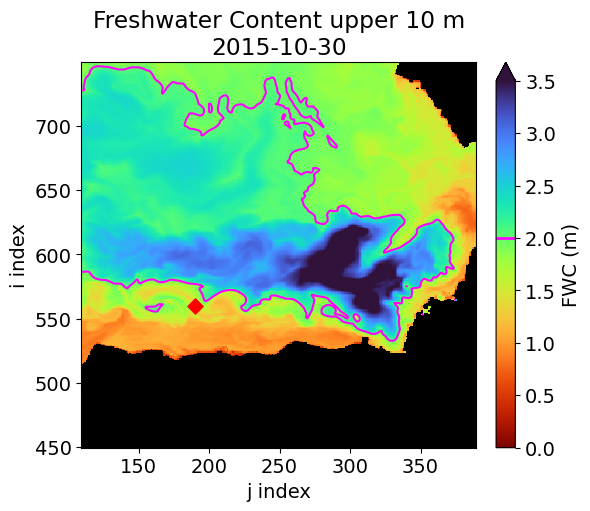

In [94]:
# draw a box for the Beaufort domain region
plt.rcParams['font.size'] = 14
fig, ax1 = plt.subplots(1,1,layout='constrained',figsize=[5.8,5])

plot = fwc_date_flip.plot(ax=ax1,vmin=0,vmax=3.5,cmap='turbo_r',cbar_kwargs={'label':'FWC (m)'})
fwc_date_flip.plot.contour(ax=ax1,levels=[2],colors='magenta')
land_rot.plot(ax=ax1,vmin=0,vmax=1,cmap='Greys',add_colorbar=False)

ax1.scatter(j,i,s=60,marker='D',color='r')

# Add a horizontal magenta line at value=2 on the colorbar
plot.colorbar.ax.axhline(2, color='magenta', linewidth=2)

ax1.set_ylabel('i index')
ax1.set_xlabel('j index')
ax1.set_title(f'Freshwater Content upper 10 m\n{date}');

## Single profile plot

## Animation

In [74]:
def plot_profiles_and_mld(date, temp_da, salt_da, sigma0, grid_beaufort, threshold_idx_da, mld_da, save_path=None):
    import matplotlib.pyplot as plt
    import numpy as np

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=[6, 4], sharey=True, layout='constrained')

    temp_da.sel(time=date).plot(ax=ax1, y='Z', color='tab:blue', marker='.')
    salt_da.sel(time=date).plot(ax=ax2, y='Z', color='tab:red', marker='.')
    sigma0.sel(time=date).plot(ax=ax3, y='Z', color='k', marker='.')

    mld_bottom = grid_beaufort.isel(k=int(threshold_idx_da.sel(time=date).values[0])).Z.values
    ax3.axhline(y=mld_bottom, color='tab:green', linestyle='dashed', label='Surface MLD')

    mld_winter_bottom = grid_beaufort.isel(k_u=9).Zu.values
    ax3.axhline(y=mld_winter_bottom, color='gray', linestyle='dashed', label='Winter MLD')
    ax3.legend()

    ax1.set_title('Temperature')
    ax2.set_title('Salinity')
    ax3.set_title('Potential Density')

    ax1.set_yticks(np.arange(0, -70, -10))
    ax1.set_yticklabels(np.arange(0, 70, 10))
    ax1.set_ylim([-60, 2])

    ax1.set_xlim([-2,3])
    ax1.set_xticks([-2,0,3])
    ax2.set_xlim([8,32])
    ax2.set_xticks([8,16,32.5])
    ax3.set_xlim([1010,1026.5])
    ax3.set_xticks([1010,1018,1026])
    
    ax1.set_xlabel("")
    ax2.set_xlabel("")
    ax3.set_xlabel("")
    
    for ax in (ax1, ax2, ax3):
        ax.set_ylabel("")
        ax.grid(linewidth=0.2)

    ax1.set_ylabel('Depth (m)')
    plt.suptitle(f'Profile on {date} at (i={i}, j={j})')

    if save_path:
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()

In [23]:
i=560
j=190

In [25]:
temp_select = temp_da.sel(time=slice('2015-08-01','2015-12-31'),i=i,j=j).load()
salt_select = salt_da.sel(time=slice('2015-08-01','2015-12-31'),i=i,j=j).load()
sigma0_select = sigma0.sel(time=slice('2015-08-01','2015-12-31'),i=i,j=j).load()
thresh_select = threshold_idx_da.sel(time=slice('2015-08-01','2015-12-31'),i=i,j=j).load()
mld_select = mld_da.sel(time=slice('2015-08-01','2015-12-31'),i=i,j=j).load()

In [44]:
import os
from datetime import datetime
import imageio

# Create a folder for frames
os.makedirs("profile_frames", exist_ok=True)

# pull out dates
dates = [str(d.values)[:10] for d in temp_select.time]

# Generate and save plots
for idx, date in enumerate(sorted(set(dates))):
    # print(f"Processing {date} ({idx+1}/{len(dates)})")
    save_path = f"profile_frames/frame_{idx:03d}.png"
    plot_profiles_and_mld(date, temp_select, salt_select, sigma0_select,
                          grid_beaufort, thresh_select, mld_select,
                          save_path=save_path)

In [45]:
# Create GIF
frames = []
frame_paths = sorted([f"profile_frames/{f}" for f in os.listdir("profile_frames") if f.endswith('.png')])
for frame_path in frame_paths:
    frames.append(imageio.v2.imread(frame_path))

imageio.mimsave("profile_animation_2015.gif", frames, duration=0.5)

## Combine profile and map

In [290]:
def plot_profiles_and_mld(
    date, temp_da, salt_da, sigma0, grid_beaufort, threshold_idx_da,
    mld_da, fwc_date_flip, land_rot, save_path=None
):
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.gridspec import GridSpec

    plt.rcParams['font.size'] = 12
    fig = plt.figure(figsize=(10, 4.5),constrained_layout=True,)
    gs = GridSpec(1, 4, width_ratios=[0.8, 0.8, 0.8, 1.6], figure=fig)

    # Set up axes
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax3 = fig.add_subplot(gs[2])
    ax4 = fig.add_subplot(gs[3])  # FWC map

    # Plot profiles
    temp_da.sel(time=date).plot(ax=ax1, y='Z', color='tab:blue', marker='.')
    salt_da.sel(time=date).plot(ax=ax2, y='Z', color='tab:red', marker='.')
    sigma0.sel(time=date).plot(ax=ax3, y='Z', color='k', marker='.')

    mld_bottom = grid_beaufort.isel(k=int(threshold_idx_da.sel(time=date).values[0])).Z.values
    ax3.axhline(y=mld_bottom, color='tab:green', linestyle='dashed', label='Surface MLD')

    mld_winter_bottom = grid_beaufort.isel(k=9).Z.values
    ax3.axhline(y=mld_winter_bottom, color='gray', linestyle='dashed', label='Winter MLD')
    ax3.legend(loc='lower left',fontsize=9)

    # Clear x-labels for first 3 plots
    for ax in (ax1, ax2, ax3):
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.grid(linewidth=0.2)
        ax.set_ylim([-60, 2])

    # Plot the FWC map on ax4
    plot = fwc_date_flip.sel(time=date).plot(ax=ax4, vmin=0, vmax=3.5, cmap='turbo_r', extend='both',
                              cbar_kwargs={'label': 'FWC (m)'})
    fwc_date_flip.sel(time=date).isel(time=0).plot.contour(ax=ax4, levels=[2], linewidths=0.8, colors='magenta')
    land_rot.plot(ax=ax4, vmin=0, vmax=1, cmap='Greys', add_colorbar=False)
    ax4.scatter(temp_select.j,temp_select.i,s=60,marker='D',color='r',label='Profile location')
    ax4.legend(loc='lower left',fontsize=9)

    # Customize colorbar ticks and labels
    cbar = plot.colorbar
    cbar.set_ticks([0, 1, 2, 3, 3.5])  # ticks you want
    cbar.set_ticklabels(['0', '1', '2', '3', '3.5'])  # labels as strings for clarity
    cbar.ax.tick_params(labelsize=10)  # optional: adjust tick label size

    # Add magenta line to the colorbar at 2
    cbar.ax.axhline(2, color='magenta', linewidth=2)

    # Add magenta line to the colorbar
    plot.colorbar.ax.axhline(2, color='magenta', linewidth=2)

    # Set titles and axis properties
    ax1.set_title('Temperature')
    ax2.set_title('Salinity')
    ax3.set_title('Potential Density')

    ax1.set_yticks(np.arange(-60, 10, 10))
    ax1.set_yticklabels(np.arange(60, -10, -10))
    ax2.set_yticklabels([])
    ax3.set_yticklabels([])

    ax1.set_xlim([-2, 3])
    ax1.set_xticks([-2, -1, 0, 1, 2, 3])
    ax2.set_xlim([8, 32.5])
    ax2.set_xticks([8, 16, 24, 32])
    # ax3.set_xlim([1008, 1026.5])
    ax3.set_xlim([1024, 1025.5])
    # ax3.set_xticks([1010, 1018, 1026])

    ax1.set_ylabel('Depth (m)')
    ax4.set_xlabel('j index')
    ax4.set_ylabel('i index')
    ax4.set_title('Freshwater Content\nupper 10m')
    ax4.set_xlim([389,110])

    plt.suptitle(f'Profile on {date} at (j={j},i={i})\n')

    if save_path:
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()

In [145]:
# open FWC dataset
fwc_yrs = xr.open_zarr('/home/jpluser/efs-mount-point/mzahn/sassie/HH/ZARR/FWC/FWC_Beaufort_alltime.ZARR')
fwc_yrs = fwc_yrs.fwc

In [255]:
# HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.mask_basin.isel(k=0)!=0).isel(i=slice(450,700),j=slice(0,500))
mask_da = HH_grid.mask_basin.isel(k=0,i=slice(450,750),j=slice(110,390))
HH_grid_land = 1 - mask_da.where(mask_da==0)
land_rot = xr.DataArray(np.rot90(HH_grid_land,3), dims=['i','j'], \
                        coords={'i': mask_da.i, 'j': mask_da.j.isel(j=slice(None, None, -1))})

In [261]:
i=555
j=190

In [262]:
fwc_select = fwc_yrs.sel(time=slice('2015-09-01','2015-12-31'))
fwc_dates_flip = xr.DataArray(np.rot90(fwc_select,3,axes=(1,2)), \
                             dims=['time','i','j'], coords={'i': fwc_select.i, \
                                                            'j': fwc_select.j.isel(j=slice(None, None, -1)), \
                                                            'time': fwc_select.time}).load()

In [263]:
temp_select = temp_da.sel(time=slice('2015-09-01','2015-12-31'),i=i,j=j).load()
salt_select = salt_da.sel(time=slice('2015-09-01','2015-12-31'),i=i,j=j).load()
sigma0_select = sigma0.sel(time=slice('2015-09-01','2015-12-31'),i=i,j=j).load()
thresh_select = threshold_idx_da.sel(time=slice('2015-09-01','2015-12-31'),i=i,j=j).load()
mld_select = mld_da.sel(time=slice('2015-09-01','2015-12-31'),i=i,j=j).load()

In [285]:
import os
from datetime import datetime
import imageio

# Create a folder for frames
os.makedirs("profile_frames", exist_ok=True)

# pull out dates
dates = [str(d.values)[:10] for d in temp_select.time]

# Generate and save plots
for idx, date in enumerate(sorted(set(dates))):
    # print(f"Processing {date} ({idx+1}/{len(dates)})")
    save_path = f"profile_frames/frame_{idx:03d}.png"
    plot_profiles_and_mld(date, temp_select, salt_select, sigma0_select,
                          grid_beaufort, thresh_select, mld_select, fwc_dates_flip, land_rot,
                          save_path=save_path)

In [265]:
# Create GIF
frames = []
frame_paths = sorted([f"profile_frames/{f}" for f in os.listdir("profile_frames") if f.endswith('.png')])
for frame_path in frame_paths:
    frames.append(imageio.v2.imread(frame_path))

imageio.mimsave("profile_animation_2015.gif", frames, duration=0.5)

## Generate one that is west of the plume

In [277]:
i=555
j=320

In [278]:
fwc_select = fwc_yrs.sel(time=slice('2015-09-01','2015-12-31'))
fwc_dates_flip = xr.DataArray(np.rot90(fwc_select,3,axes=(1,2)), \
                             dims=['time','i','j'], coords={'i': fwc_select.i, \
                                                            'j': fwc_select.j.isel(j=slice(None, None, -1)), \
                                                            'time': fwc_select.time}).load()

In [279]:
temp_select = temp_da.sel(time=slice('2015-09-01','2015-12-31'),i=i,j=j).load()
salt_select = salt_da.sel(time=slice('2015-09-01','2015-12-31'),i=i,j=j).load()
sigma0_select = sigma0.sel(time=slice('2015-09-01','2015-12-31'),i=i,j=j).load()
thresh_select = threshold_idx_da.sel(time=slice('2015-09-01','2015-12-31'),i=i,j=j).load()
mld_select = mld_da.sel(time=slice('2015-09-01','2015-12-31'),i=i,j=j).load()

In [280]:
dates[-3:]

['2015-12-29', '2015-12-30', '2015-12-31']

In [291]:
import os
from datetime import datetime
import imageio

# Create a folder for frames
os.makedirs("profile_frames", exist_ok=True)

# pull out dates
dates = [str(d.values)[:10] for d in temp_select.time]

# Generate and save plots
for idx, date in enumerate(sorted(set(dates[-3:]))):
    # print(f"Processing {date} ({idx+1}/{len(dates)})")
    save_path = f"profile_frames/frame_{idx:03d}.png"
    plot_profiles_and_mld(date, temp_select, salt_select, sigma0_select,
                          grid_beaufort, thresh_select, mld_select, fwc_dates_flip, land_rot,
                          save_path=save_path)

In [276]:
# Create GIF
frames = []
frame_paths = sorted([f"profile_frames/{f}" for f in os.listdir("profile_frames") if f.endswith('.png')])
for frame_path in frame_paths:
    frames.append(imageio.v2.imread(frame_path))

imageio.mimsave("profile_animation_west_2015.gif", frames, duration=0.5)